In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from datetime import datetime

In [37]:
PROCESSED_DATA_PATH = "../data/processed"
VISUALIZATION_PATH = "visualizations"
os.makedirs(VISUALIZATION_PATH, exist_ok=True)

In [38]:
thematic_files = [f for f in os.listdir(PROCESSED_DATA_PATH) if f.startswith("thematic_results_")]

Successfully loaded: ../data/processed\thematic_results_20250609_012551.csv


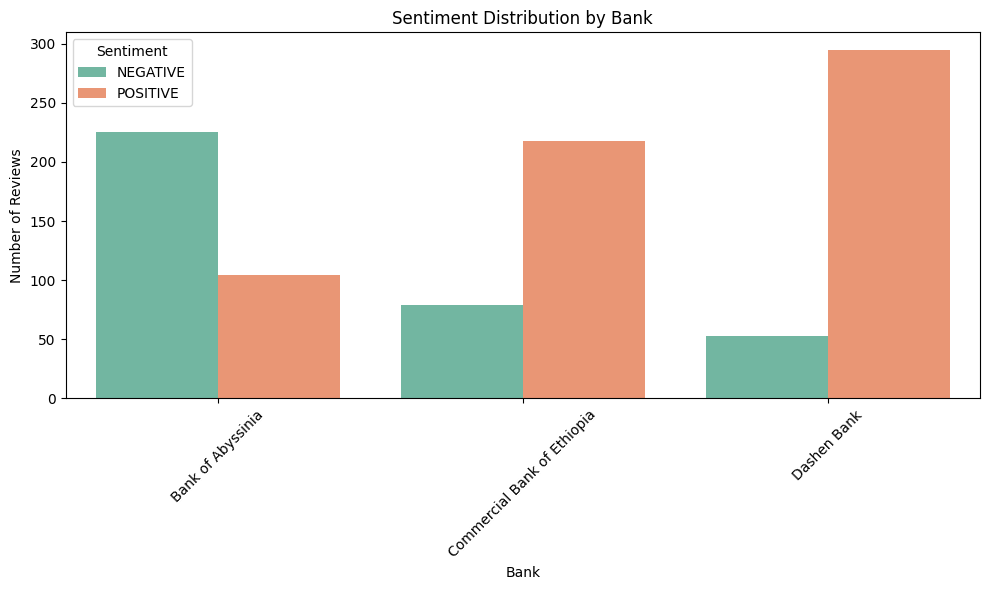

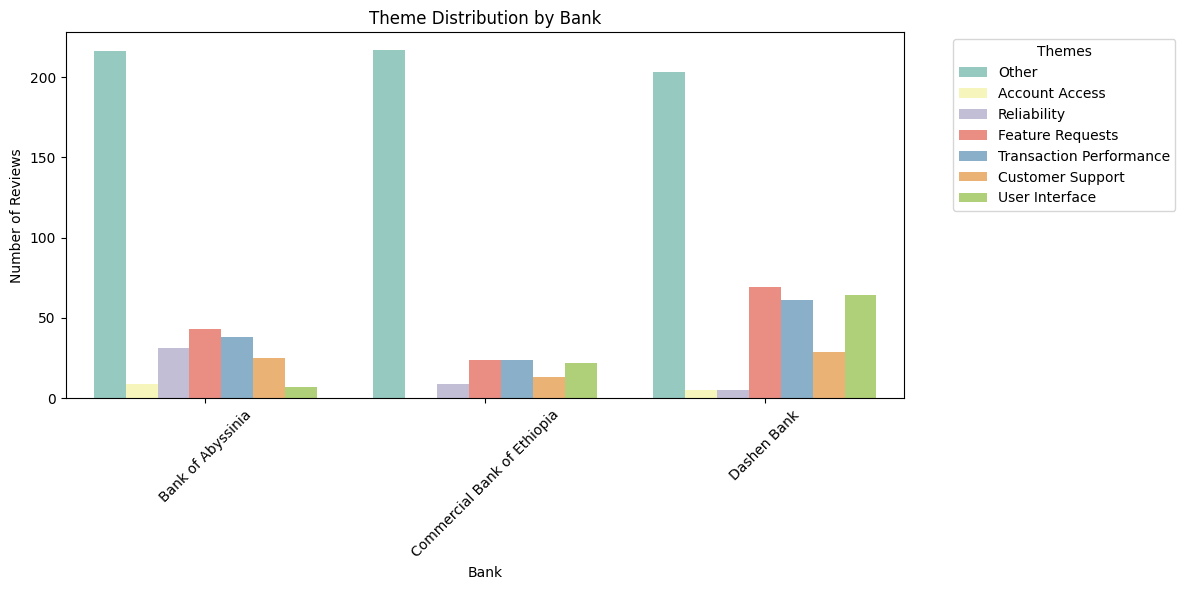

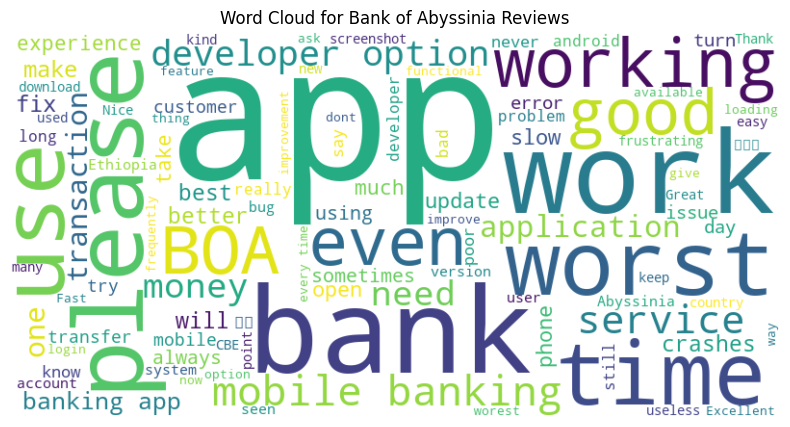

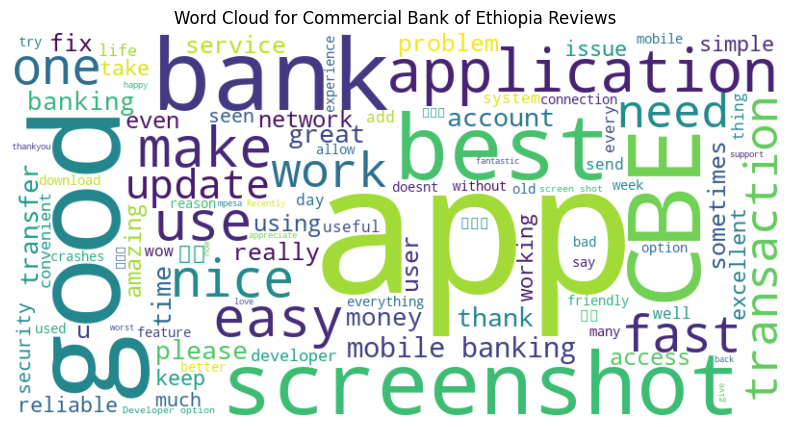

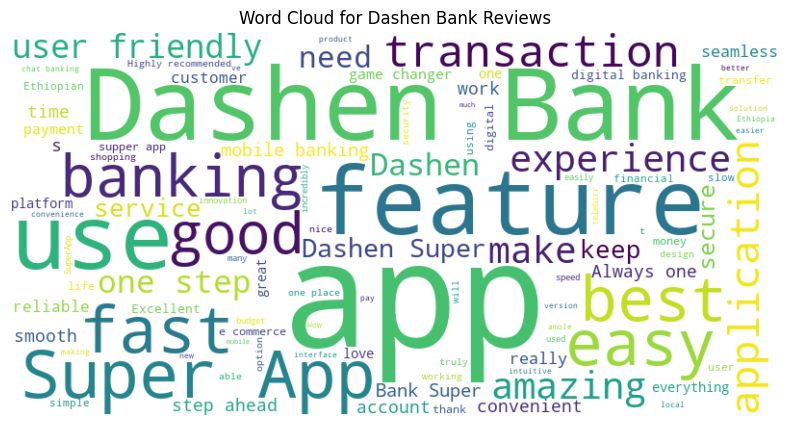

In [39]:
if not thematic_files:
    print(f"Error: No files starting with 'thematic_results_' found in '{PROCESSED_DATA_PATH}'. Please ensure files are present.")
else:
    latest_file = max(thematic_files, key=lambda x: os.path.getctime(os.path.join(PROCESSED_DATA_PATH, x)))
    data = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, latest_file))
    print(f"Successfully loaded: {os.path.join(PROCESSED_DATA_PATH, latest_file)}")
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x="bank_name", hue="sentiment_label", palette="Set2")
    plt.title("Sentiment Distribution by Bank")
    plt.xlabel("Bank")
    plt.ylabel("Number of Reviews")
    plt.legend(title="Sentiment")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(VISUALIZATION_PATH, f"sentiment_distribution_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"))
    plt.show()
    if 'themes' in data.columns and data['themes'].apply(lambda x: isinstance(x, str) and x.startswith('[')).any():
        from ast import literal_eval
        data['themes'] = data['themes'].apply(literal_eval)
        theme_data = data.explode("themes")
    elif 'themes' in data.columns:
        theme_data = data.explode("themes")
    else:
        print("Warning: 'themes' column not found or not in expected list format. Skipping theme distribution plot.")
        theme_data = pd.DataFrame()
    if not theme_data.empty:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=theme_data, x="bank_name", hue="themes", palette="Set3")
        plt.title("Theme Distribution by Bank")
        plt.xlabel("Bank")
        plt.ylabel("Number of Reviews")
        plt.legend(title="Themes", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(os.path.join(VISUALIZATION_PATH, f"theme_distribution_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"))
        plt.show()

    if "rating" in data.columns and "sentiment_label" in data.columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x="rating", hue="sentiment_label", palette="Set2")
        plt.title("Sentiment Distribution by Rating")
        plt.xlabel("Rating")
        plt.ylabel("Number of Reviews")
        plt.legend(title="Sentiment")
        plt.tight_layout()
        plt.savefig(os.path.join(VISUALIZATION_PATH, f"sentiment_vs_rating_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"))
        plt.show()
    else:
        print("Warning: 'rating' or 'sentiment_label' column not found. Skipping sentiment vs rating plot")

    if "bank_name" in data.columns and "review_text" in data.columns:
        for bank in data["bank_name"].unique():
            bank_reviews = data[data["bank_name"] == bank]["review_text"]
            text = " ".join(bank_reviews.dropna().astype(str))
            if text:
                wordcloud = WordCloud(width=800, height=400, background_color="white", max_words=100).generate(text)
                plt.figure(figsize=(10, 5))
                plt.imshow(wordcloud, interpolation="bilinear")
                plt.axis("off")
                plt.title(f"Word Cloud for {bank} Reviews")
                plt.savefig(os.path.join(VISUALIZATION_PATH, f"wordcloud_{bank}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"))
                plt.show()
            else:
                print(f"No review text found for {bank}. Skipping word cloud generation.")
    else:
        print("Warning: 'bank_name' or 'review_text' column not found. Skipping word cloud generation.")
